In [14]:
from google.colab import files
uploaded = files.upload()


Saving 2) Stock Prices Data Set.csv to 2) Stock Prices Data Set.csv


# Task 1: Build a Random Forest Classifier

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Load the dataset
try:
    df = pd.read_csv('2) Stock Prices Data Set.csv')
    print("Data loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: '2) Stock Prices Data Set.csv' not found. Please ensure the file is uploaded to your Colab session.")
    print("You can re-upload it by running the previous cell (from google.colab import files; uploaded = files.upload()).")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")

Data loaded successfully.


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [16]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df['price_increased'] = (df['close'] > df['open']).astype(int)
if 'symbol' in df.columns and df['symbol'].dtype == 'object':
    df = pd.get_dummies(df, columns=['symbol'], drop_first=True)

print("Preprocessing complete. Displaying first few rows of the processed DataFrame:")
display(df.head())

Preprocessing complete. Displaying first few rows of the processed DataFrame:


,date,open,high,low,close,volume,price_increased,symbol_AAL,symbol_AAP,symbol_AAPL,...,symbol_XL,symbol_XLNX,symbol_XOM,symbol_XRAY,symbol_XRX,symbol_XYL,symbol_YUM,symbol_ZBH,symbol_ZION,symbol_ZTS
0,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,1,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
X = df.drop(columns=['date', 'close', 'price_increased'])
y = df['price_increased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (397977, 508)
Shape of X_test: (99495, 508)
Shape of y_train: (397977,)
Shape of y_test: (99495,)


In [18]:
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


In [19]:
y_pred = model.predict(X_test)

print("#### Test Set Evaluation ####")
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\n#### Cross-Validation ####")
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", np.mean(cv_scores))

#### Test Set Evaluation ####
Precision: 0.5260692240458348
Recall: 0.5144479622091562
F1 Score: 0.35279842149282065

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.00      0.01     48338
           1       0.51      1.00      0.68     51157

    accuracy                           0.51     99495
   macro avg       0.53      0.50      0.34     99495
weighted avg       0.53      0.51      0.35     99495


#### Cross-Validation ####
Cross Validation Scores: [0.51460877 0.51473943 0.51486522 0.51496573 0.51451344]
Average CV Score: 0.5147385182057039


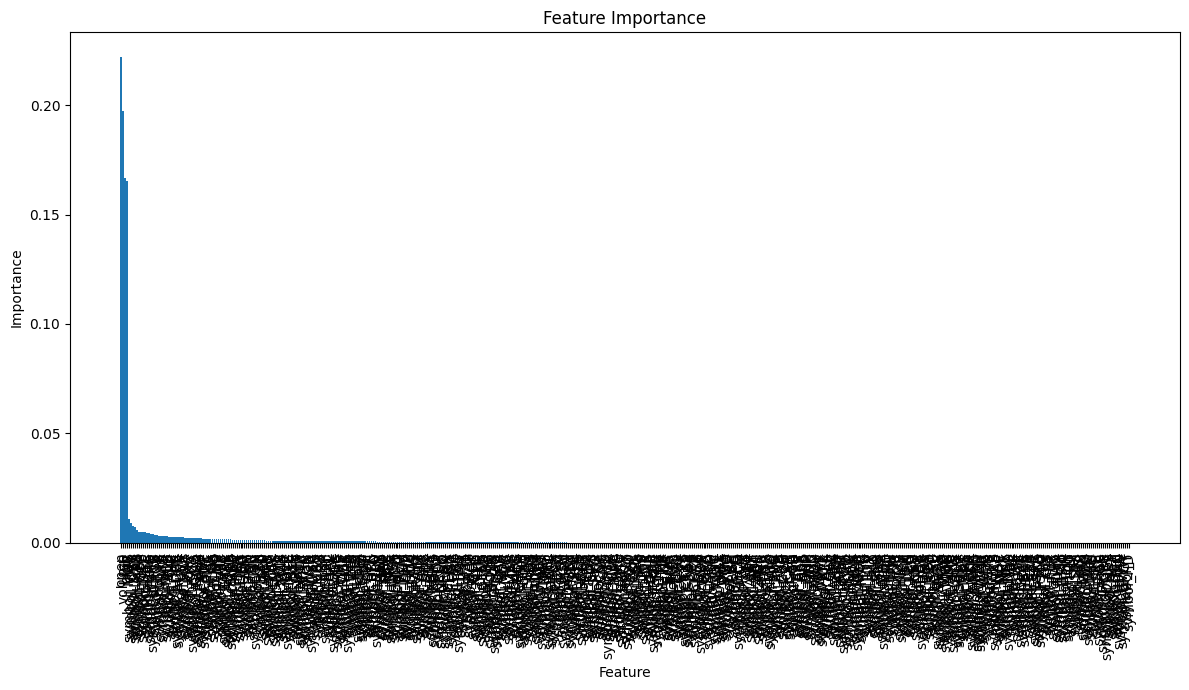

In [20]:
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12,7))
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Task 3: Neural Networks with TensorFlow/Keras

This task involves building and evaluating a simple feed-forward neural network using TensorFlow's Keras API for a classification task. I will use the Fashion MNIST dataset for this demonstration.

TensorFlow Version: 2.19.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


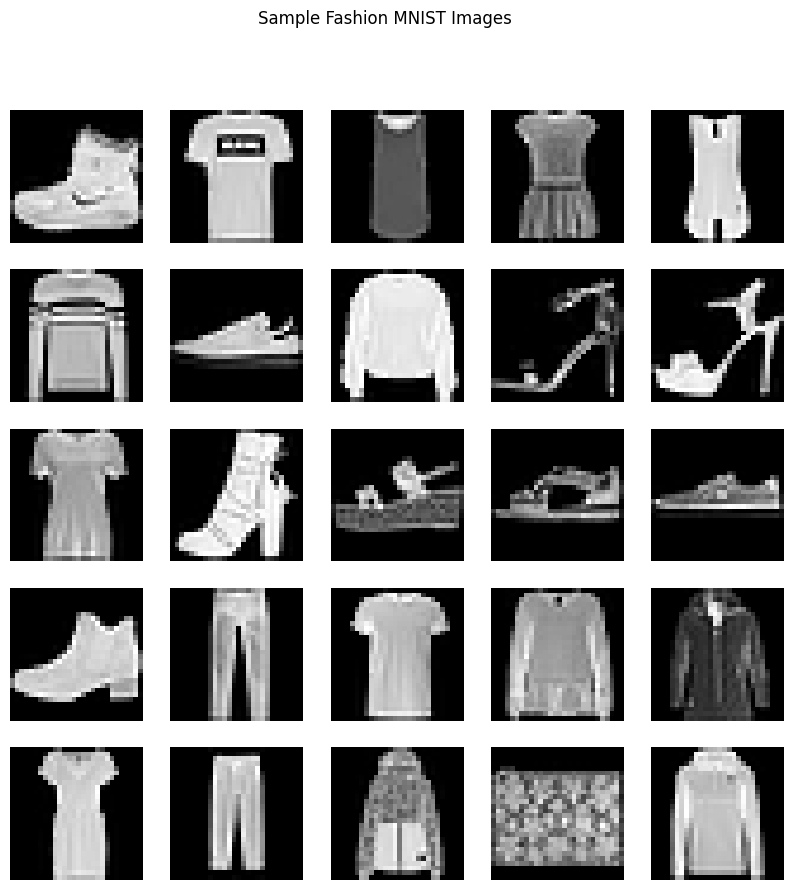

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

print(f"TensorFlow Version: {tf.__version__}")

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

# Display first few images to verify
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
plt.suptitle('Sample Fashion MNIST Images')
plt.show()

In [22]:
x_train_scaled = x_train.astype('float32') / 255.0
x_test_scaled = x_test.astype('float32') / 255.0
x_train_flattened = x_train_scaled.reshape(-1, 28*28)
x_test_flattened = x_test_scaled.reshape(-1, 28*28)

print(f"Flattened training data shape: {x_train_flattened.shape}")
print(f"Flattened test data shape: {x_test_flattened.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [23]:
model = keras.Sequential([
    keras.Input(shape=(28*28,)), # Input layer expecting flattened 28x28 images
    layers.Dense(128, activation='relu', name='hidden_layer_1'), # First hidden layer with 128 neurons and ReLU activation
    layers.Dense(64, activation='relu', name='hidden_layer_2'),  # Second hidden layer with 64 neurons and ReLU activation
    layers.Dense(10, activation='softmax', name='output_layer')   # Output layer with 10 neurons (for 10 classes) and softmax activation
])

# Display the model's architecture summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train_flattened, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

print("Model training complete.")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8156 - loss: 0.5171 - val_accuracy: 0.8538 - val_loss: 0.4030
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8613 - loss: 0.3801 - val_accuracy: 0.8482 - val_loss: 0.4251
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8749 - loss: 0.3416 - val_accuracy: 0.8670 - val_loss: 0.3642
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8810 - loss: 0.3181 - val_accuracy: 0.8690 - val_loss: 0.3513
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8894 - loss: 0.2980 - val_accuracy: 0.8859 - val_loss: 0.3232
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8944 - loss: 0.2834 - val_accuracy: 0.8656 - val_loss: 0.3661
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8973 - loss: 0.2733 - val_accuracy: 0.8876 - val_loss: 0.3244
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9027 - loss: 0.2

In [25]:
loss, accuracy = model.evaluate(x_test_flattened, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8721 - loss: 0.3724

Test Loss: 0.3724
Test Accuracy: 0.8721


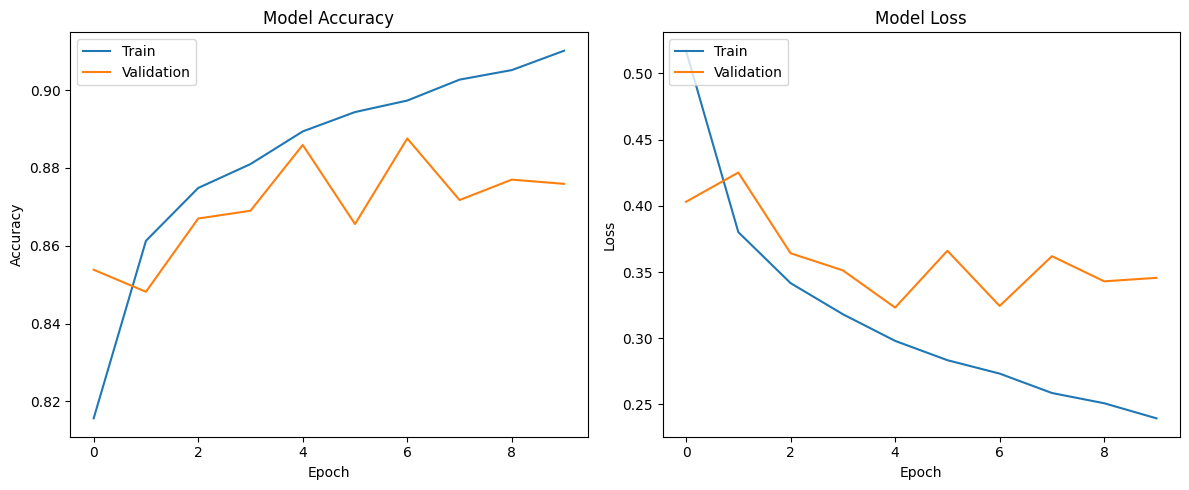

In [26]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()